In [1]:
import pandas as pd


# File paths
keywords_csv = "C:\\Users\jaimy\PycharmProjects\Minisymposium-blok-2\keywords_coverage_details.csv"
entities_csv = "C:\\Users\jaimy\PycharmProjects\Minisymposium-blok-2\entities_coverage_details.csv"

# Load the data into DataFrames
keywords_df = pd.read_csv(keywords_csv)
entities_df = pd.read_csv(entities_csv)

# Enhance the DataFrame views by splitting the overlapping data into columns
keywords_df['Overlapping Keywords List'] = keywords_df['Overlapping Keywords'].apply(lambda x: x.split(", ") if pd.notna(x) else [])
entities_df['Overlapping Entities List'] = entities_df['Overlapping Entities'].apply(lambda x: x.split(", ") if pd.notna(x) else [])

# Display the Keywords DataFrame
print("Keywords Coverage Table:")
display(keywords_df)

# Display the Entities DataFrame
print("\nEntities Coverage Table:")
display(entities_df)



Keywords Coverage Table:


,Original Keywords,Summary Keywords,Overlapping Keywords,Overlapping Keywords List
0,"decaan, waar, studeren, helpen, eisen, praat, ...","brief, ,, ondertekend, minister, Eppo, Bruins,...","decaan, hebt, studeren, opleiding, havo, succe...","[decaan, hebt, studeren, opleiding, havo, succ..."
1,Original Keywords,Summary Keywords,Overlapping Keywords,[Overlapping Keywords]
2,"decaan, waar, studeren, helpen, eisen, praat, ...","brief, ``, Full, Content, '', lijkt, uitgebrei...","mbo, decaan, waar, mag, stap, opleiding, mento...","[mbo, decaan, waar, mag, stap, opleiding, ment..."
3,Original Keywords,Summary Keywords,Overlapping Keywords,[Overlapping Keywords]
4,"decaan, waar, studeren, helpen, eisen, praat, ...","brief, ,, ondertekend, minister, Eppo, Bruins,...","mbo, decaan, havo, keuze, mentor, succes, bege...","[mbo, decaan, havo, keuze, mentor, succes, beg..."
...,...,...,...,...
486,"kunt, stage, weten, www, school, we, studie, j...","brief, gericht, mbo-studenten, Robbert, Dijkgr...","school, studie, plannen, maken, mbo, studenten","[school, studie, plannen, maken, mbo, studenten]"
487,Original Keywords,Summary Keywords,Overlapping Keywords,[Overlapping Keywords]
488,"kunt, stage, weten, www, school, we, studie, j...","belangrijkste, boodschap, brief, Ministerie, O...","studie, maken, gaan, mbo, studenten","[studie, maken, gaan, mbo, studenten]"
489,Original Keywords,Summary Keywords,Overlapping Keywords,[Overlapping Keywords]



Entities Coverage Table:


,Original Entities,Summary Entities,Overlapping Entities,Overlapping Entities List
0,"Voor, Bruin, Onderwijs, Haag, B, Marië, De, We...","Bruin, vmbo, Marië, Paul, Ep","Ep, Bruin, Marië","[Ep, Bruin, Marië]"
1,Original Entities,Summary Entities,Overlapping Entities,[Overlapping Entities]
2,"Voor, Bruin, Onderwijs, Haag, B, Marië, De, We...","Voor, en, Full Con, vmbo, Onderwijs, Web, In, ...","Voor, De, Onderwijs","[Voor, De, Onderwijs]"
3,Original Entities,Summary Entities,Overlapping Entities,[Overlapping Entities]
4,"Voor, Bruin, Onderwijs, Haag, B, Marië, De, We...","Bruin, Onderwijs, Marië, Cultuur en Wetenschap...","Ep, Bruin, Onderwijs, Marië","[Ep, Bruin, Onderwijs, Marië]"
...,...,...,...,...
486,"Geld Sta, Haag, Nederland, mbo, O, De, B, Rijn","Robbert Dijk, Wetenschap, Cultuur, Onderwijs, M",NaN,[]
487,Original Entities,Summary Entities,Overlapping Entities,[Overlapping Entities]
488,"Geld Sta, Haag, Nederland, mbo, O, De, B, Rijn","Ministerie, mbo, Ministerie van Onderwijs, Cul...",mbo,[mbo]
489,Original Entities,Summary Entities,Overlapping Entities,[Overlapping Entities]


In [2]:
import pandas as pd

# Load the original CSV containing the individual results
input_csv_path = 'C:\\Users\\jaimy\\PycharmProjects\\Minisymposium-blok-2\\evaluation_results_dutch.csv'  # Replace with your input file path
df = pd.read_csv(input_csv_path)

# Display the first few rows to inspect the data
df.head()



,letter,summary,perplexity,similarity,keyword_coverage,entity_coverage,topic_coverage,blanc_score,reduction_factor
0,Brief 1 aan eindexamenleerlingen in het vmbo.pdf,Brief 1 aan eindexamenleerlingen in het vmbo(C...,48326.580693,0.603740,0.269231,0.214286,0.0,0.222222,0.262346
1,Brief 1 aan eindexamenleerlingen in het vmbo.pdf,Brief 1 aan eindexamenleerlingen in het vmbo(F...,39356.463812,0.502411,0.307692,0.000000,1.0,0.213213,0.393519
2,Brief 1 aan eindexamenleerlingen in het vmbo.pdf,Brief 1 aan eindexamenleerlingen in het vmbo(G...,38417.752047,0.596405,0.192308,0.500000,0.2,0.153153,0.334877
3,Brief 1 aan eindexamenleerlingen in het vmbo.pdf,Brief 1 aan eindexamenleerlingen in het vmbo(G...,45017.713739,0.675068,0.307692,0.285714,0.0,0.222222,0.316358
4,Brief 1 aan eindexamenleerlingen in het vmbo.pdf,Brief 1 aan eindexamenleerlingen in het vmbo(G...,40016.934670,0.612996,0.423077,0.000000,0.2,0.243243,0.368827


In [3]:
# Extract model names from the summary column (assuming the model name is within parentheses)
df['model'] = df['summary'].apply(lambda x: x.split('(')[-1].split(')')[0])

# Group by model and calculate the averages for each metric
model_results = df.groupby('model').agg(
    perplexity_avg=('perplexity', 'mean'),
    similarity_avg=('similarity', 'mean'),
    keyword_coverage_avg=('keyword_coverage', 'mean'),
    entity_coverage_avg=('entity_coverage', 'mean'),
    topic_coverage_avg=('topic_coverage', 'mean'),
    # bert_precision_avg=('bert_precision', 'mean'),
    # bert_recall_avg=('bert_recall', 'mean'),
    # bert_f1_avg=('bert_f1', 'mean'),
    blanc_score_avg=('blanc_score', 'mean'),
    reduction_factor_avg=('reduction_factor', 'mean')
).reset_index()

# Show the aggregated results in the notebook
model_results

,model,perplexity_avg,similarity_avg,keyword_coverage_avg,entity_coverage_avg,topic_coverage_avg,blanc_score_avg,reduction_factor_avg
0,Claude-3-haiku,4.172805e+04,0.645869,0.344821,0.225417,0.433333,0.260127,0.473180
1,Fietje-2,3.676688e+04,0.604321,0.329615,0.128617,0.533333,0.196978,0.532954
2,GPT-4o,4.316921e+04,0.655933,0.338075,0.292282,0.266667,0.227021,0.443896
3,Geitje-7B-Ultra,4.030702e+04,0.607876,0.211016,0.142157,0.166667,0.140784,0.473760
4,Granite-3.1-2b-instruct,3.973117e+04,0.585992,0.383518,0.151633,0.300000,0.250611,0.495839
5,Llama-3-ChocoLlama-8B,7.982422e+06,0.629612,0.415600,0.118029,0.500000,0.226122,0.882976
6,Llama-3.1-8B,1.033322e+06,0.617800,0.417288,0.319502,0.500000,0.246488,0.380269
7,Mistral-7B,1.314774e+06,0.600555,0.394990,0.114082,0.433333,0.217129,0.306636
8,Mistral-Large-24.11,4.006740e+04,0.619328,0.391822,0.280379,0.566667,0.272088,0.434574
9,Schaapje-2B-Chat-V1.0,3.997492e+04,0.590798,0.276315,0.180990,0.233333,0.171130,0.429267


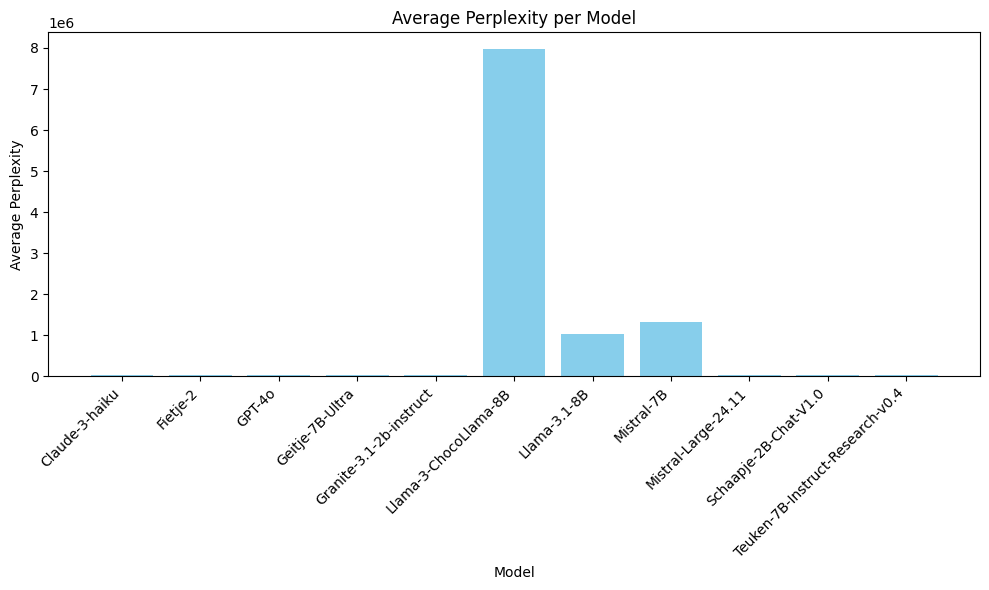

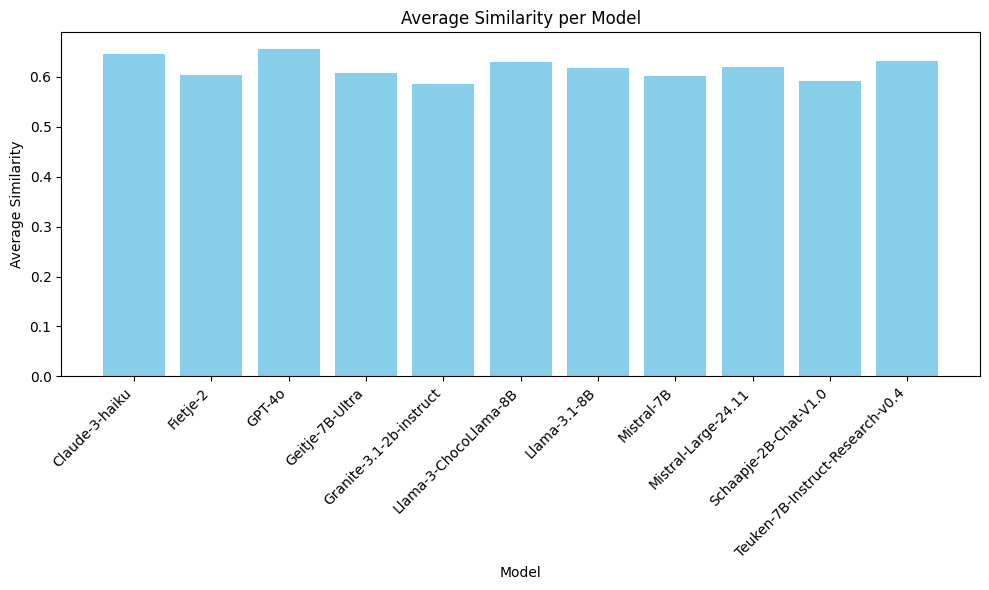

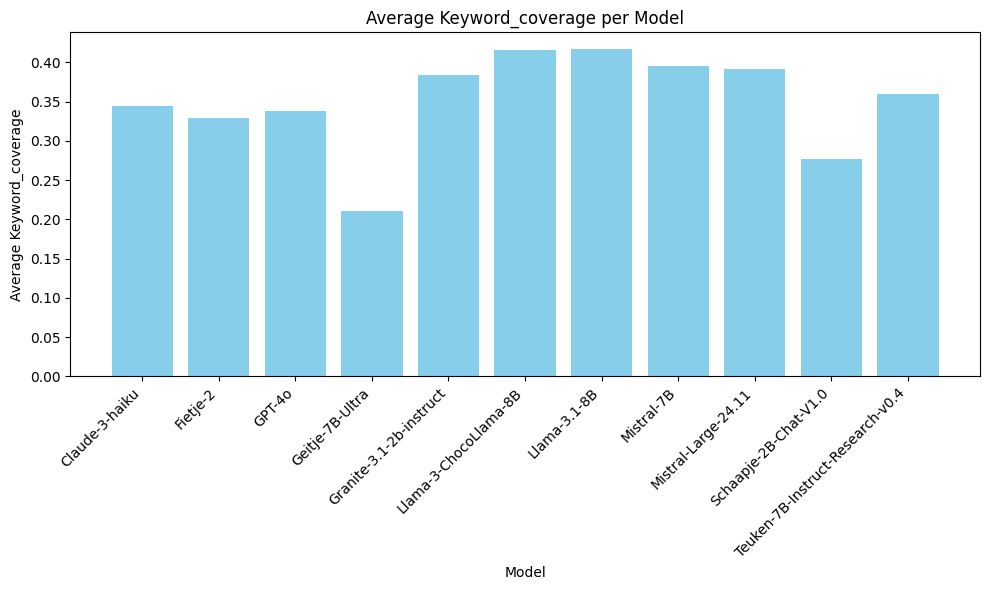

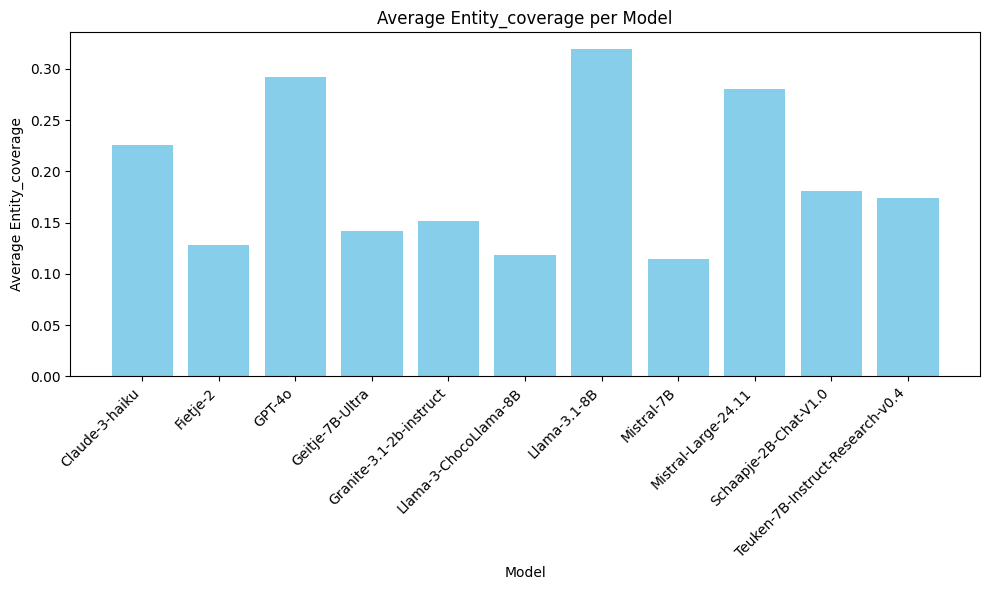

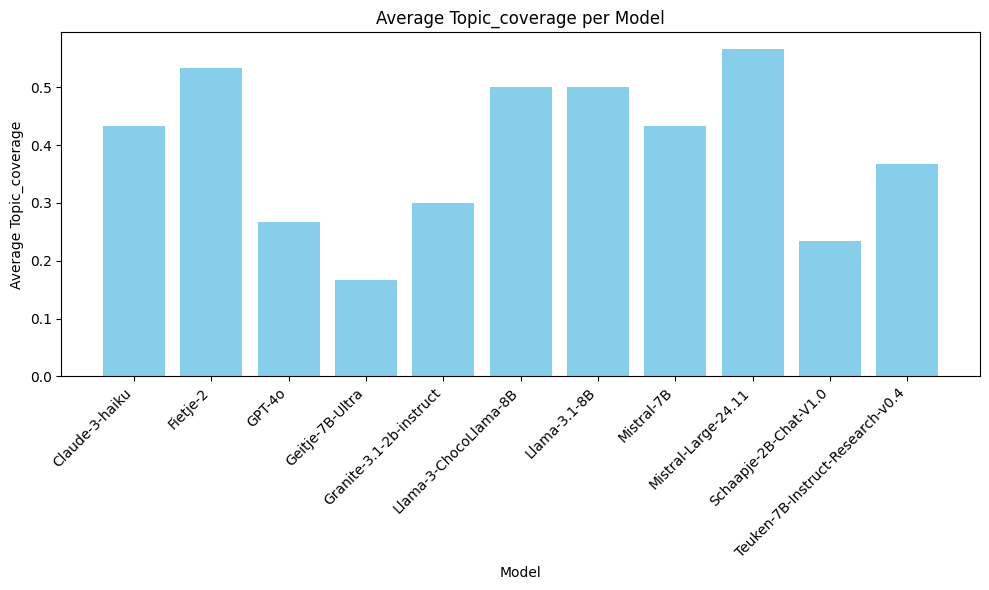

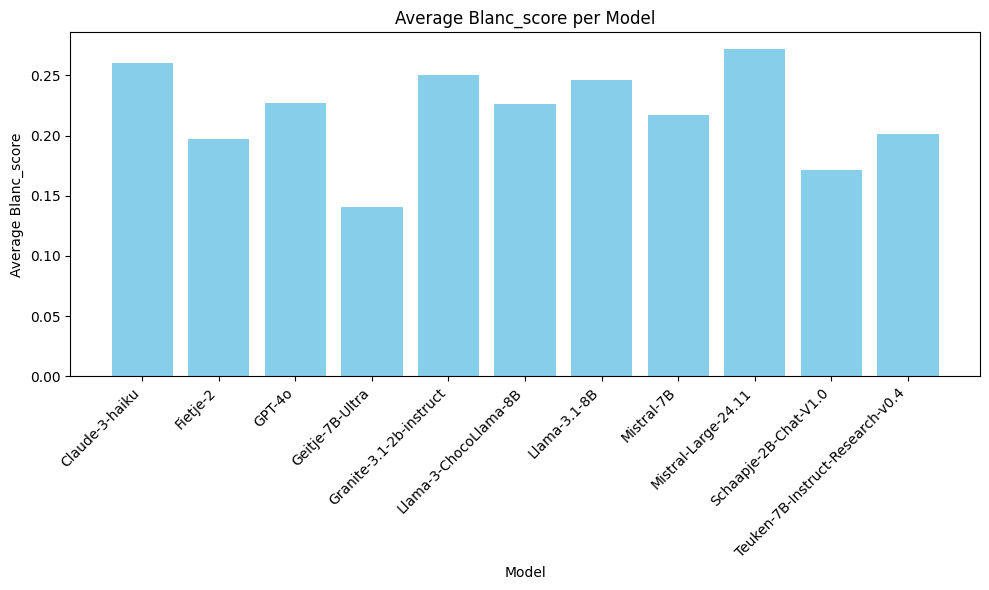

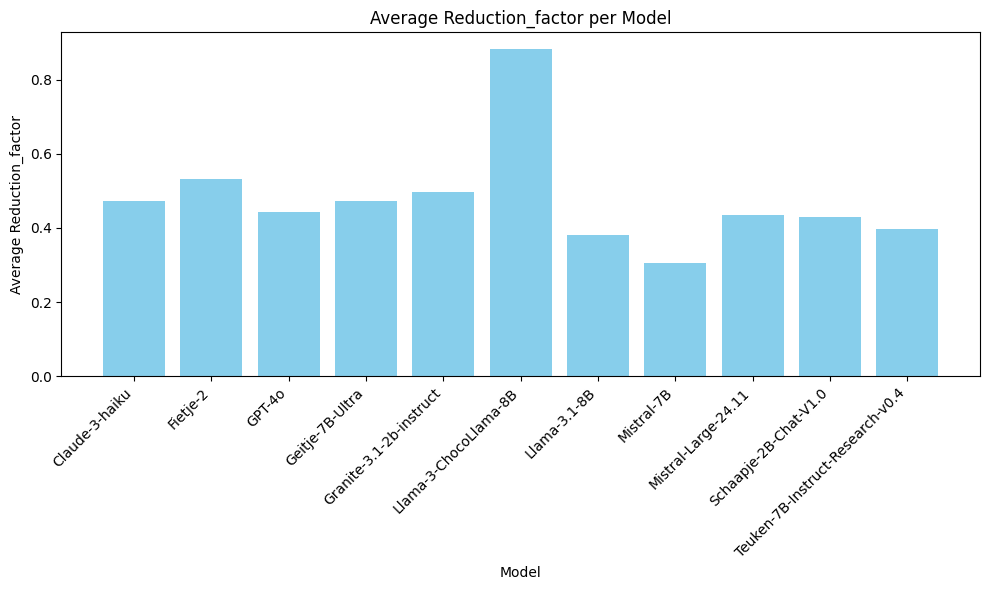

In [4]:
import matplotlib.pyplot as plt

# Set up a plot for each metric and display them one by one
# metrics = ['perplexity', 'similarity', 'keyword_coverage','entity_coverage', 'topic_coverage', 'bert_precision', 'bert_recall', 'bert_f1', 'reduction_factor']
metrics = ['perplexity', 'similarity', 'keyword_coverage','entity_coverage', 'topic_coverage','blanc_score'  ,'reduction_factor']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(model_results['model'], model_results[f'{metric}_avg'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel(f'Average {metric.capitalize()}')
    plt.title(f'Average {metric.capitalize()} per Model')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Save the aggregated results to a new CSV file (optional)
output_csv_path = 'model_evaluation_aggregated_results.csv'  # Path to save the results
model_results.to_csv(output_csv_path, index=False)